In [13]:
#234567890#234567890#234567890#234567890#234567890#234567890#234567890#23456789
using GraphRecipes
using Graphs
using Luxor
using Plots
using Primes: factor
using StatsBase

In [2]:
planet_diameters = [
    4879 12104 12756 3475 6792 142984 120536 51118 49528 2370]
planet_names = [
    "Mercury", "Venus", "Earth", "Moon", "Mars", "Jupiter", "Saturn", 
    "Uranus", "Neptune", "Pluto"]
dimenx = 1000
dimeny = 500

500

In [3]:
@png begin 
    dscale = 500.0
    origin(Point(planet_diameters[1] / (2*dscale), dimeny / 2))
    ledge = 0.0
    diameter = 0
    fontface("Liberation Sans")
    fontsize(32)
    for i in 1:10
        ledge += diameter / 2.0
        name = planet_names[i]
        diameter = planet_diameters[i] / dscale
        ledge += diameter / 2.0
        setcolor("black")
        setdash("solid")
        circle(Point(ledge, 0), diameter / 2.0, :stroke)
        txtstart = Point(100 * (i - 1), 180 + 35*(i % 2))
        text(name, txtstart)
        setcolor("blue")
        setdash("dot")
        line(txtstart, Point(ledge, 0), :stroke)
    end
end dimenx dimeny "./planets.png"

LoadError: UndefVarError: `text` not defined in `Main`
Hint: It looks like two or more modules export different bindings with this name, resulting in ambiguity. Try explicitly importing it from a particular module, or qualifying the name with the module it should come from.
Hint: a global variable of this name also exists in Plots.
Hint: a global variable of this name also exists in Cairo.
Hint: a global variable of this name also exists in Luxor.
Hint: a global variable of this name also exists in GR.

In [4]:
;open planets.png

The file /Users/damiansp/Learning/julia/practical/07_diagrams_animations/planets.png does not exist.


In [5]:
creatures = [
    "Striped bass", "Atlantic croaker", "White perch", "Summer flounder",
    "Clearnose skate", "Bay anchovy", "Worms", "Mysids", "Amphipods",
    "Juvenile weakfish", "Sand shrimp", "Mantis shrimp", "Razor clams",
    "Juvenile Atlantic croaker"]
foodchain = SimpleDiGraph(14)
food_dict = Dict([creatures[i] => i for i in 1:14])

Dict{String, Int64} with 14 entries:
  "Juvenile Atlantic croaker" => 14
  "Atlantic croaker"          => 2
  "Summer flounder"           => 4
  "Razor clams"               => 13
  "White perch"               => 3
  "Clearnose skate"           => 5
  "Worms"                     => 7
  "Mysids"                    => 8
  "Striped bass"              => 1
  "Amphipods"                 => 9
  "Juvenile weakfish"         => 10
  "Sand shrimp"               => 11
  "Mantis shrimp"             => 12
  "Bay anchovy"               => 6

In [6]:
function preyson(predator, prey)
    add_edge!(foodchain, food_dict[predator], food_dict[prey])
end

preyson (generic function with 1 method)

In [7]:
preyson("Striped bass", "Worms")
preyson("Striped bass", "Amphipods")
preyson("Striped bass", "Mysids")
preyson("Striped bass", "Bay anchovy")
preyson("Atlantic croaker", "Mysids")
preyson("Atlantic croaker", "Worms")
preyson("White perch", "Worms")
preyson("White perch", "Amphipods")
preyson("Summer flounder", "Bay anchovy")
preyson("Summer flounder", "Mysids")
preyson("Summer flounder", "Juvenile weakfish")
preyson("Summer flounder", "Sand shrimp")
preyson("Summer flounder", "Mantis shrimp")
preyson("Clearnose skate", "Mantis shrimp")
preyson("Clearnose skate", "Razor clams")
preyson("Clearnose skate", "Juvenile Atlantic croaker")

true

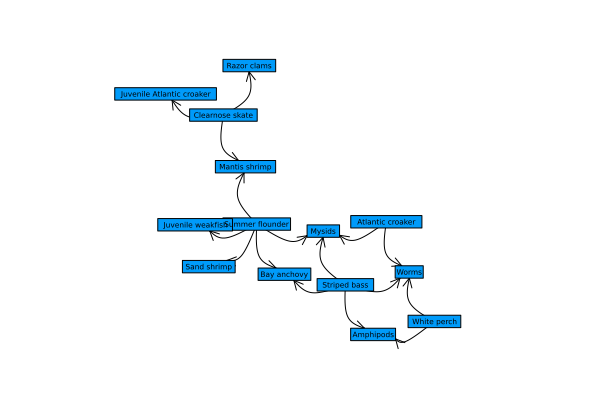

In [8]:
graphplot(
    foodchain; 
    names=creatures, nodeshape=:rect, fontsize=5, nodesize=0.14, method=:stress)

In [9]:
foodchain_matrix = adjacency_matrix(foodchain)

14×14 SparseArrays.SparseMatrixCSC{Int64, Int64} with 16 stored entries:
 ⋅  ⋅  ⋅  ⋅  ⋅  1  1  1  1  ⋅  ⋅  ⋅  ⋅  ⋅
 ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  1  1  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅
 ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  1  ⋅  1  ⋅  ⋅  ⋅  ⋅  ⋅
 ⋅  ⋅  ⋅  ⋅  ⋅  1  ⋅  1  ⋅  1  1  1  ⋅  ⋅
 ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  1  1  1
 ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅
 ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅
 ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅
 ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅
 ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅
 ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅
 ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅
 ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅
 ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅

In [10]:
function factree(n)
    factors = factor(Vector, n)
    lf = length(factors)
    if lf == 1
        println("$n is prime")
        return
    end
    names = [n; n ÷ factors[1]; factors[1]]
    for f in factors[2:end - 1]
        push!(names, names[end - 1] ÷ f, f)
    end
    ln = length(names)
    a = zeros(ln, ln)
    println("Prime factors: $factors")
    j = 1
    i = 1
    a[1, 2] = 1
    a[1, 3] = 1
    for i in 2:2:ln - 3
        a[i, i + 2] = 1
        a[i, i + 3] = 1
    end
    graphplot(
        a;
        nodeshape=:circle,
        nodesize=0.12 + log10(n) * 0.1,
        axis_buffer=0.3,
        curves=true,
        color=:black,
        linewidth=2,
        names=names,
        fontsize=10,
        method=:buchheim)
end

factree (generic function with 1 method)

Prime factors: [2, 2, 2, 2, 3, 3, 3, 5, 7, 13]


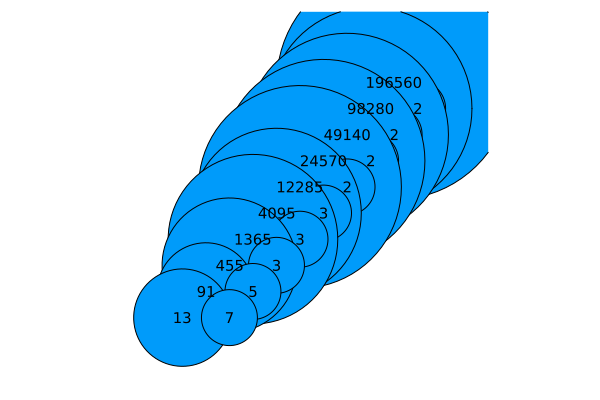

In [24]:
ps = [2, 3, 5, 7, 11, 13]
w = [1/2, 1/3, 1/5, 1/7, 1/11, 1/13]
w /= sum(w)
n = prod(StatsBase.sample(ps, Weights(w), 10))
factree(n)

In [25]:
function power(n)
    return function(x)
        x^n
    end
end

power (generic function with 1 method)

In [26]:
p = power(5)
q = x -> x^5
p(4) == q(4) == 4^5

true

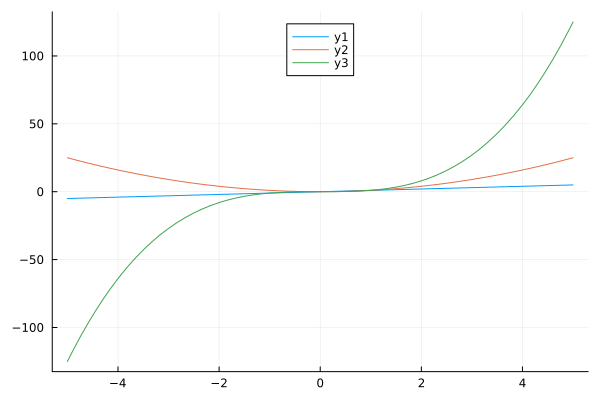

In [27]:
plot([power(1), power(2), power(3)]; legend=:top)